# Projeto de Análise de Atrasos de Voos

## Introdução

Este projeto tem como objetivo analisar uma base de dados de voos, aeroportos e companhias aéreas, realizando uma Análise Exploratória de Dados (EDA) para compreender o comportamento das variáveis, identificar padrões, tratar valores ausentes e gerar insights relevantes.

Em seguida, são desenvolvidos:
- um problema de classificação, para prever se um voo irá atrasar ou não
- um problema de regressão, para prever quantos minutos o atraso irá durar
- uma etapa de modelagem não supervisionada, com PCA e KMeans, para identificar grupos de aeroportos com comportamentos semelhantes

A base principal utilizada contém informações sobre voos, como horários programados e reais, atrasos, distância, cancelamentos e causas de atraso. Além disso, foram utilizadas tabelas auxiliares com informações de aeroportos e companhias aéreas para enriquecer a análise.

## Objetivos

Os objetivos deste trabalho são:

- realizar o EDA da base de voos
- investigar os dados com estatísticas descritivas
- tratar valores ausentes de forma adequada
- construir visualizações que revelem insights
- desenvolver um modelo de classificação para prever se um voo atrasará ou não
- desenvolver um modelo de regressão para prever o tempo de atraso
- comparar pelo menos dois algoritmos em cada tarefa utilizando métricas adequadas
- aplicar modelagem não supervisionada com PCA e KMeans

In [ ]:
# 1. Imports e configurações
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Leitura e integração dos dados

In [56]:
# 2. Localização dos arquivos
print("Diretório atual:", Path.cwd())

possible_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd().parent.parent
]

project_root = None
for p in possible_roots:
    if (p / "data" / "raw" / "flights.csv").exists():
        project_root = p
        break

if project_root is None:
    raise FileNotFoundError("Não encontrei data/raw/flights.csv em nenhum caminho esperado.")

print("Project root encontrado:", project_root)

flights_path = project_root / "data" / "raw" / "flights.csv"
airports_path = project_root / "data" / "raw" / "airports.csv"
airlines_path = project_root / "data" / "raw" / "airlines.csv"

Diretório atual: c:\Users\Giovanna\Downloads\flights-ml\notebooks
Project root encontrado: c:\Users\Giovanna\Downloads\flights-ml


In [57]:
# 3. Leitura dos dados
flights = pd.read_csv(
    flights_path,
    dtype={
        "ORIGIN_AIRPORT": "string",
        "DESTINATION_AIRPORT": "string",
        "AIRLINE": "string",
        "TAIL_NUMBER": "string"
    },
    low_memory=False
)

airports = pd.read_csv(airports_path)
airlines = pd.read_csv(airlines_path)

print("flights:", flights.shape)
print("airports:", airports.shape)
print("airlines:", airlines.shape)

display(flights.head())
display(airports.head())
display(airlines.head())

flights: (5819079, 31)
airports: (322, 7)
airlines: (14, 2)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [58]:
# 4. Join das tabelas
df = flights.merge(
    airlines.rename(columns={"AIRLINE": "AIRLINE_NAME"}),
    how="left",
    left_on="AIRLINE",
    right_on="IATA_CODE"
)

airports_origin = airports.rename(columns={
    "IATA_CODE": "ORIGIN_AIRPORT",
    "AIRPORT": "ORIGIN_AIRPORT_NAME",
    "CITY": "ORIGIN_CITY",
    "STATE": "ORIGIN_STATE",
    "COUNTRY": "ORIGIN_COUNTRY",
    "LATITUDE": "ORIGIN_LATITUDE",
    "LONGITUDE": "ORIGIN_LONGITUDE"
})

df = df.merge(airports_origin, how="left", on="ORIGIN_AIRPORT")

airports_dest = airports.rename(columns={
    "IATA_CODE": "DESTINATION_AIRPORT",
    "AIRPORT": "DEST_AIRPORT_NAME",
    "CITY": "DEST_CITY",
    "STATE": "DEST_STATE",
    "COUNTRY": "DEST_COUNTRY",
    "LATITUDE": "DEST_LATITUDE",
    "LONGITUDE": "DEST_LONGITUDE"
})

df = df.merge(airports_dest, how="left", on="DESTINATION_AIRPORT")

print("Shape após joins:", df.shape)
display(df.head())

Shape após joins: (5819079, 45)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_COUNTRY,DEST_LATITUDE,DEST_LONGITUDE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AA,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,AS,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619


# Análise Exploratória de Dados (EDA)

## Visão geral da base

In [59]:
# ============================================================
# 5. Visão geral da base
# ============================================================
print("Quantidade de linhas e colunas:", df.shape)
print("Tipos das variáveis:")
display(df.dtypes.to_frame("dtype").head(50))

print("Resumo estatístico:")
display(df.describe(include="all").T.head(50))

Quantidade de linhas e colunas: (5819079, 45)
Tipos das variáveis:


,dtype
YEAR,int64
MONTH,int64
DAY,int64
DAY_OF_WEEK,int64
AIRLINE,object
FLIGHT_NUMBER,int64
TAIL_NUMBER,string
ORIGIN_AIRPORT,object
DESTINATION_AIRPORT,object
SCHEDULED_DEPARTURE,int64


Resumo estatístico:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,NaN,NaN,NaN,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,NaN,NaN,NaN,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,NaN,NaN,NaN,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,5819079.0,NaN,NaN,NaN,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
TAIL_NUMBER,5804358,4897,N480HA,3768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,628,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,629,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,5819079.0,NaN,NaN,NaN,1329.60247,483.751821,1.0,917.0,1325.0,1730.0,2359.0


In [60]:
# ============================================================
# 6. Análise de valores ausentes
# ============================================================
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing": missing,
    "percentual": missing_pct
})

display(missing_df[missing_df["missing"] > 0].head(40))

,missing,percentual
CANCELLATION_REASON,5729195,98.46
AIR_SYSTEM_DELAY,4755640,81.72
AIRLINE_DELAY,4755640,81.72
SECURITY_DELAY,4755640,81.72
WEATHER_DELAY,4755640,81.72
LATE_AIRCRAFT_DELAY,4755640,81.72
DEST_LATITUDE,490775,8.43
DEST_LONGITUDE,490775,8.43
ORIGIN_LATITUDE,490770,8.43
ORIGIN_LONGITUDE,490770,8.43


## Tratamento de valores ausentes

In [61]:
# ============================================================
# 7. Tratamento inicial de valores ausentes
# ============================================================

# 1. atrasos específicos (faz sentido preencher com 0)
specific_delay_cols = [
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY"
]

for c in specific_delay_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# 2. motivo de cancelamento
if "CANCELLATION_REASON" in df.columns:
    df["CANCELLATION_REASON"] = df["CANCELLATION_REASON"].fillna("None")

# 3. colunas textuais
text_fill_cols = [
    "ORIGIN_CITY", "DEST_CITY",
    "ORIGIN_AIRPORT_NAME", "DEST_AIRPORT_NAME",
    "AIRLINE_NAME"
]

for c in text_fill_cols:
    if c in df.columns:
        df[c] = df[c].fillna("Unknown")

# 4. tempos operacionais → mediana
time_cols = ["TAXI_OUT", "TAXI_IN", "AIR_TIME", "ELAPSED_TIME", "SCHEDULED_TIME"]

for c in time_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].median())

# 5. criar base limpa (sem cancelados/desviados)
df_model_base = df[(df["CANCELLED"] == 0) & (df["DIVERTED"] == 0)].copy()

# 6. agora sim tratar delays principais
for c in ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]:
    if c in df_model_base.columns:
        df_model_base[c] = df_model_base[c].fillna(0)

print("Base original:", df.shape)
print("Base para modelagem:", df_model_base.shape)

Base original: (5819079, 45)
Base para modelagem: (5714008, 45)


## Feature engineering

In [62]:
# ============================================================
# 8. Feature engineering
# ============================================================
df_model_base["IS_DELAYED"] = (df_model_base["ARRIVAL_DELAY"] > 15).astype(int)

df_model_base["SCHEDULED_DEPARTURE"] = pd.to_numeric(
    df_model_base["SCHEDULED_DEPARTURE"],
    errors="coerce"
)
df_model_base["DEPARTURE_HOUR"] = df_model_base["SCHEDULED_DEPARTURE"] // 100

def period(hour):
    if pd.isna(hour):
        return "Unknown"
    hour = int(hour)
    if hour < 6:
        return "Madrugada"
    elif hour < 12:
        return "Manhã"
    elif hour < 18:
        return "Tarde"
    else:
        return "Noite"

df_model_base["PERIOD"] = df_model_base["DEPARTURE_HOUR"].apply(period)

df_model_base["ROUTE"] = (
    df_model_base["ORIGIN_AIRPORT"].astype(str)
    + " -> "
    + df_model_base["DESTINATION_AIRPORT"].astype(str)
)

def delay_category(x):
    if x <= 0:
        return "No prazo/adiantado"
    elif x <= 15:
        return "Atraso leve"
    elif x <= 60:
        return "Atraso moderado"
    else:
        return "Atraso severo"

df_model_base["DELAY_CATEGORY"] = df_model_base["ARRIVAL_DELAY"].apply(delay_category)

display(df_model_base.head())

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,IATA_CODE,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DEST_AIRPORT_NAME,DEST_CITY,DEST_STATE,DEST_COUNTRY,DEST_LATITUDE,DEST_LONGITUDE,IS_DELAYED,DEPARTURE_HOUR,PERIOD,ROUTE,DELAY_CATEGORY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,None,0.0,0.0,0.0,0.0,0.0,AS,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,0,0,Madrugada,ANC -> SEA,No prazo/adiantado
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,None,0.0,0.0,0.0,0.0,0.0,AA,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,0,0,Madrugada,LAX -> PBI,No prazo/adiantado
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,None,0.0,0.0,0.0,0.0,0.0,US,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313,0,0,Madrugada,SFO -> CLT,Atraso leve
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,None,0.0,0.0,0.0,0.0,0.0,AA,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056,0,0,Madrugada,LAX -> MIA,No prazo/adiantado
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,None,0.0,0.0,0.0,0.0,0.0,AS,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,0,0,Madrugada,SEA -> ANC,No prazo/adiantado


## Estatísticas descritivas principais

In [63]:
# ============================================================
# 9. Estatísticas descritivas principais
# ============================================================
print("Percentual de voos cancelados na base original:", round(df["CANCELLED"].mean() * 100, 2), "%")
print("Percentual de voos desviados na base original:", round(df["DIVERTED"].mean() * 100, 2), "%")
print("Percentual de voos atrasados (>15 min) na base de modelagem:", round(df_model_base["IS_DELAYED"].mean() * 100, 2), "%")

display(
    df_model_base[
        ["ARRIVAL_DELAY", "DEPARTURE_DELAY", "DISTANCE", "AIR_TIME", "TAXI_OUT", "WEATHER_DELAY"]
    ].describe().T
)

Percentual de voos cancelados na base original: 1.54 %
Percentual de voos desviados na base original: 0.26 %
Percentual de voos atrasados (>15 min) na base de modelagem: 17.91 %


,count,mean,std,min,25%,50%,75%,max
ARRIVAL_DELAY,5714008.0,4.407057,39.271297,-87.0,-13.0,-5.0,8.0,1971.0
DEPARTURE_DELAY,5714008.0,9.294842,36.889724,-82.0,-5.0,-2.0,7.0,1988.0
DISTANCE,5714008.0,824.456903,608.661990,31.0,373.0,650.0,1065.0,4983.0
AIR_TIME,5714008.0,113.511628,72.230822,7.0,60.0,94.0,144.0,690.0
TAXI_OUT,5714008.0,16.065498,8.882449,1.0,11.0,14.0,19.0,225.0
WEATHER_DELAY,5714008.0,0.542567,8.887775,0.0,0.0,0.0,0.0,1211.0


IS_DELAYED
0    4690510
1    1023498
Name: count, dtype: int64

IS_DELAYED
0    82.09
1    17.91
Name: proportion, dtype: float64

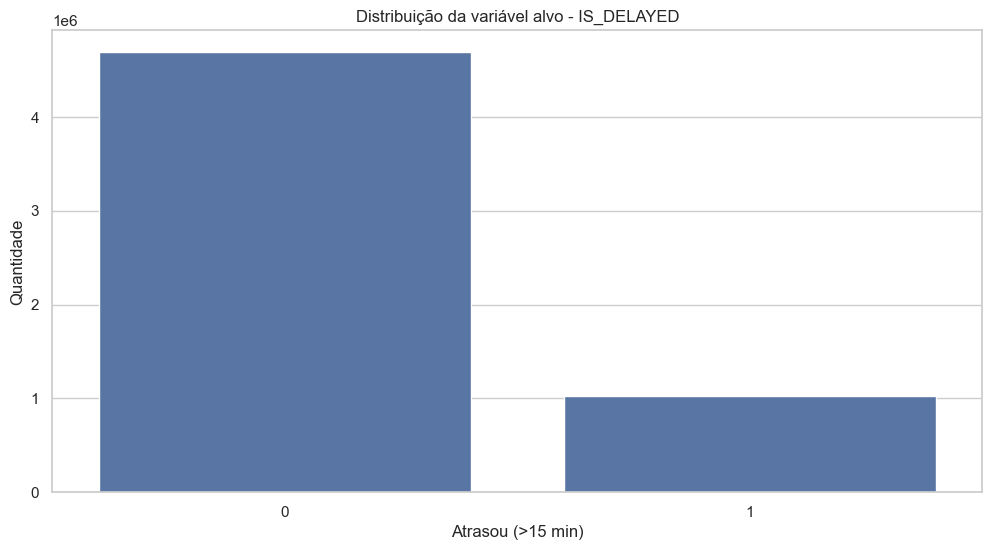

In [64]:
# ============================================================
# 10. Balanceamento da variável alvo de classificação
# ============================================================
display(df_model_base["IS_DELAYED"].value_counts())
display((df_model_base["IS_DELAYED"].value_counts(normalize=True) * 100).round(2))

sns.countplot(x="IS_DELAYED", data=df_model_base)
plt.title("Distribuição da variável alvo - IS_DELAYED")
plt.xlabel("Atrasou (>15 min)")
plt.ylabel("Quantidade")
plt.show()

## Visualizações e insights

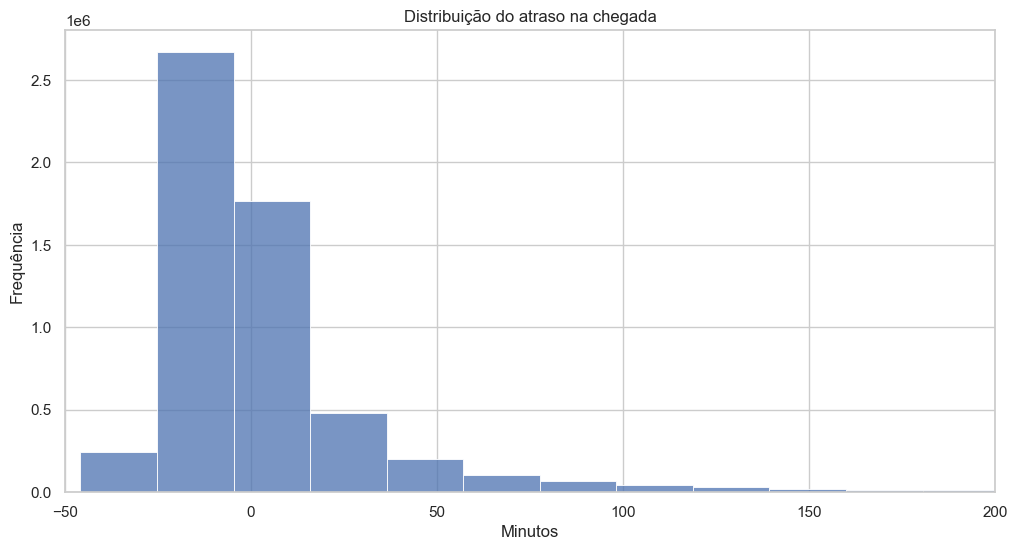

In [65]:
# ============================================================
# 11. Distribuição do atraso de chegada
# ============================================================
sns.histplot(df_model_base["ARRIVAL_DELAY"], bins=100)
plt.xlim(-50, 200)
plt.title("Distribuição do atraso na chegada")
plt.xlabel("Minutos")
plt.ylabel("Frequência")
plt.show()

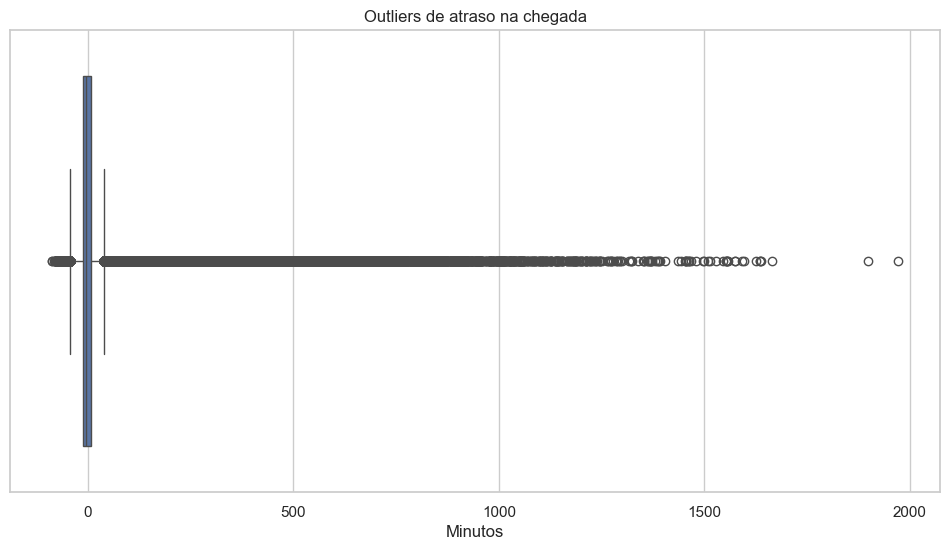

In [66]:
# ============================================================
# 12. Outliers de atraso
# ============================================================
sns.boxplot(x=df_model_base["ARRIVAL_DELAY"])
plt.title("Outliers de atraso na chegada")
plt.xlabel("Minutos")
plt.show()

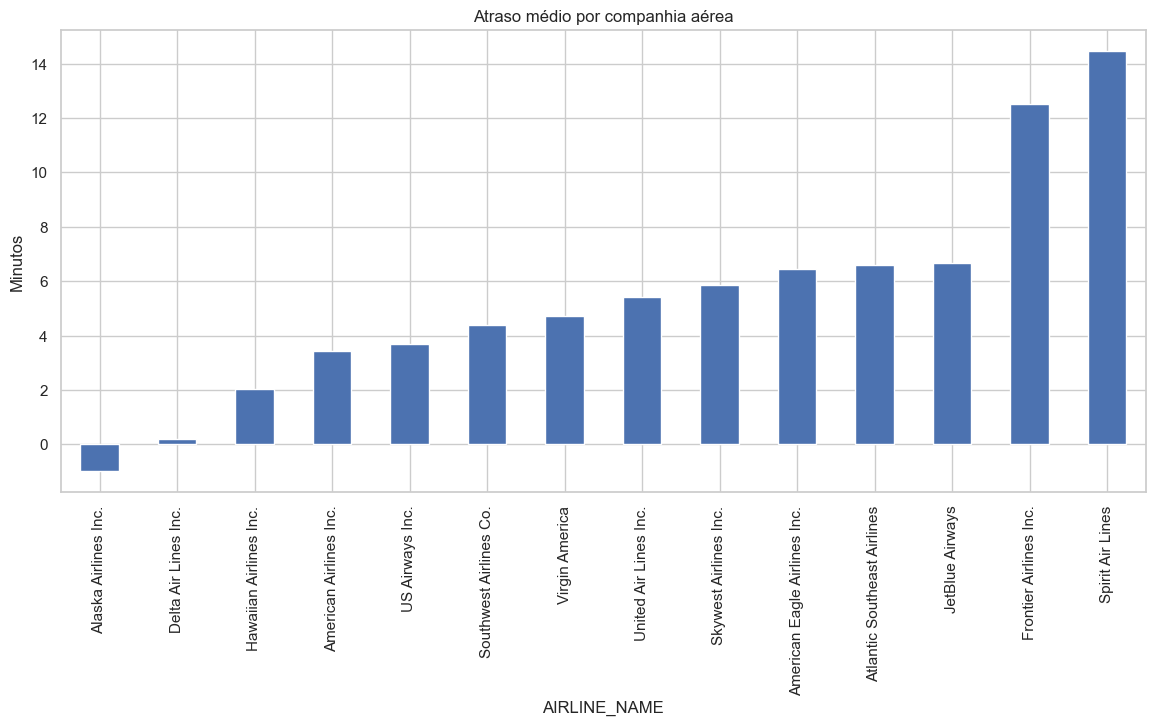

In [67]:
# ============================================================
# 13. Atraso médio por companhia aérea
# ============================================================
delay_airline = (
    df_model_base.groupby("AIRLINE_NAME")["ARRIVAL_DELAY"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(14, 6))
delay_airline.plot(kind="bar")
plt.title("Atraso médio por companhia aérea")
plt.ylabel("Minutos")
plt.show()

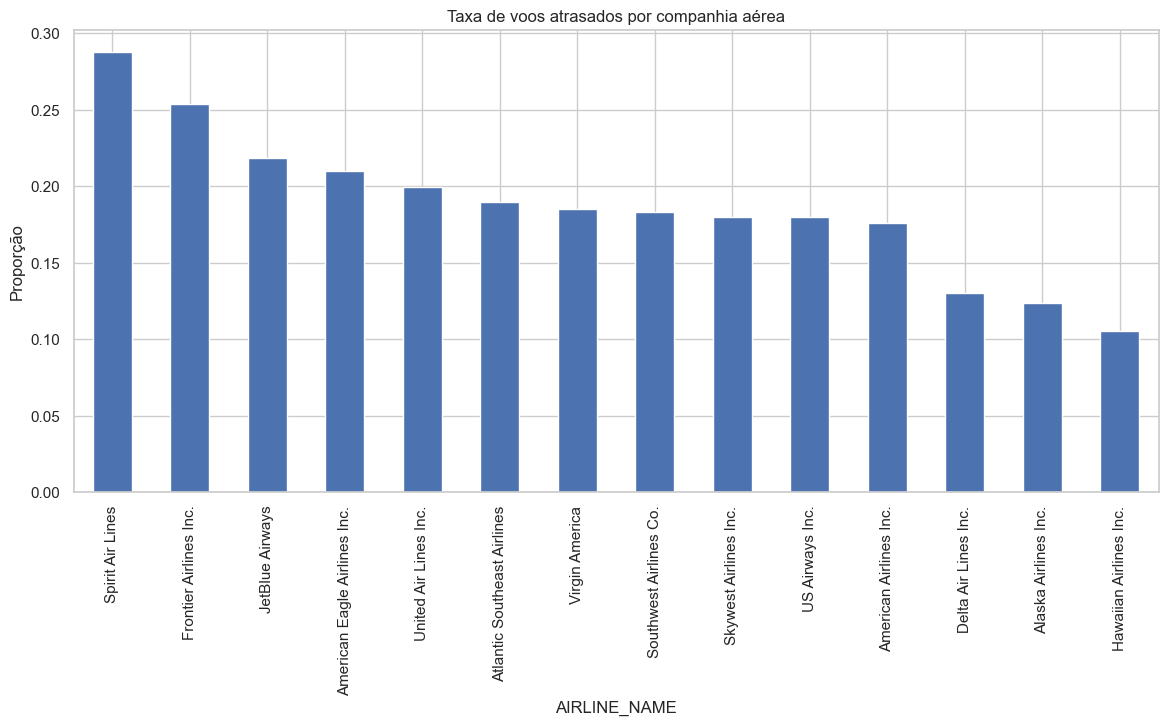

In [68]:
# ============================================================
# 14. Taxa de atraso por companhia aérea
# ============================================================
delay_rate_airline = (
    df_model_base.groupby("AIRLINE_NAME")["IS_DELAYED"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))
delay_rate_airline.plot(kind="bar")
plt.title("Taxa de voos atrasados por companhia aérea")
plt.ylabel("Proporção")
plt.show()

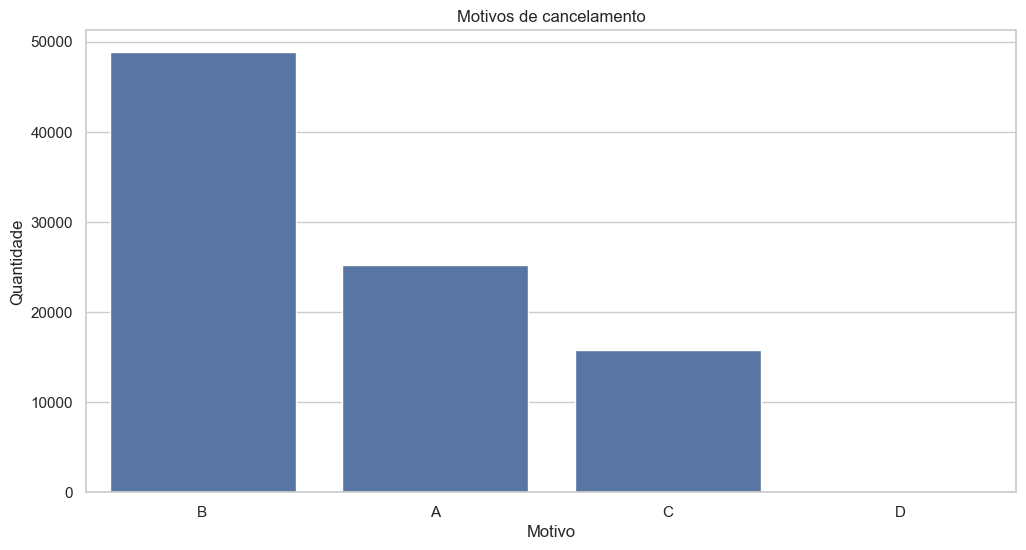

In [69]:
# ============================================================
# 15. Motivos de cancelamento na base original
# ============================================================
cancel_reason = (
    df[df["CANCELLED"] == 1]["CANCELLATION_REASON"]
    .value_counts()
)

sns.barplot(x=cancel_reason.index, y=cancel_reason.values)
plt.title("Motivos de cancelamento")
plt.xlabel("Motivo")
plt.ylabel("Quantidade")
plt.show()

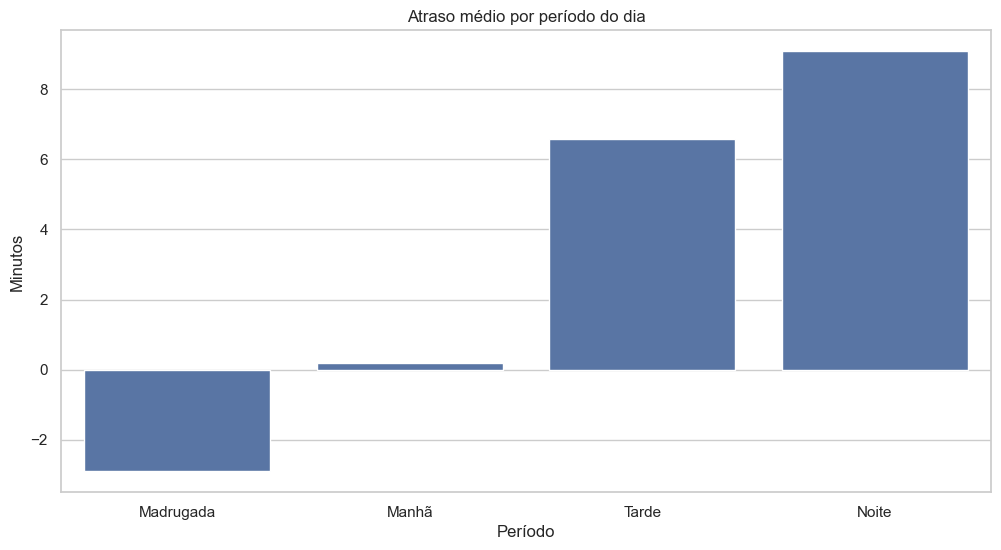

In [70]:
# ============================================================
# 16. Atraso médio por período do dia
# ============================================================
period_delay = (
    df_model_base.groupby("PERIOD")["ARRIVAL_DELAY"]
    .mean()
    .reindex(["Madrugada", "Manhã", "Tarde", "Noite", "Unknown"])
    .dropna()
)

sns.barplot(x=period_delay.index, y=period_delay.values)
plt.title("Atraso médio por período do dia")
plt.xlabel("Período")
plt.ylabel("Minutos")
plt.show()

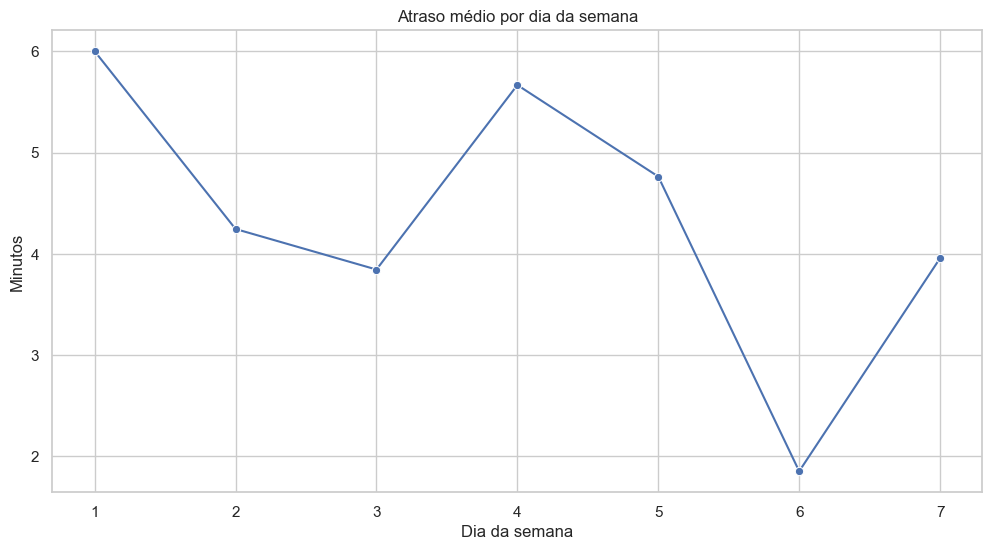

In [71]:
# ============================================================
# 17. Atraso médio por dia da semana
# ============================================================
day_delay = df_model_base.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()

sns.lineplot(x=day_delay.index, y=day_delay.values, marker="o")
plt.title("Atraso médio por dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("Minutos")
plt.show()

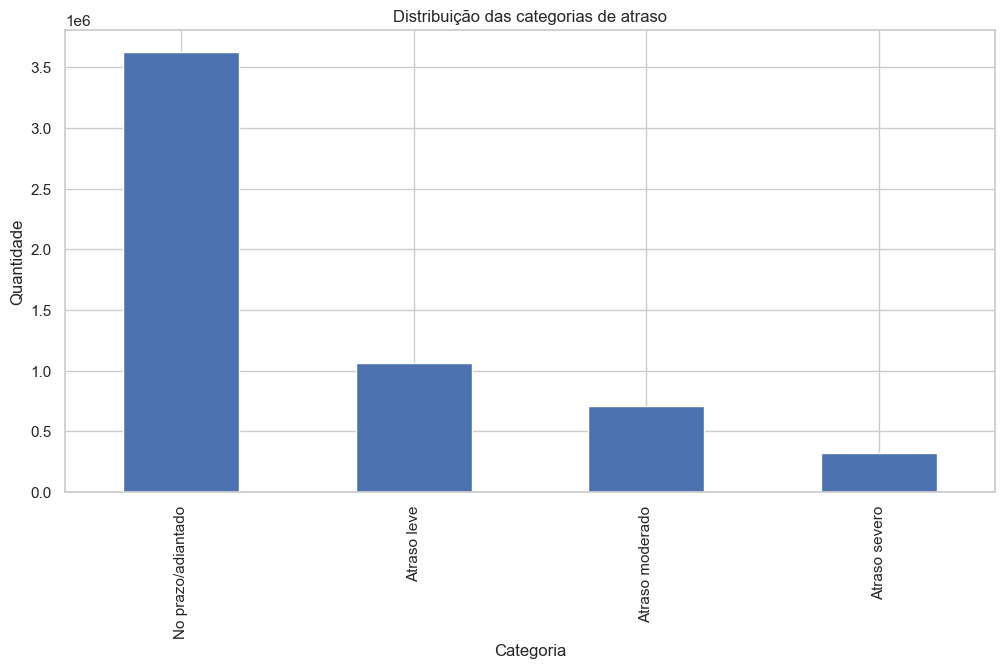

In [72]:
# ============================================================
# 18. Distribuição das categorias de atraso
# ============================================================
df_model_base["DELAY_CATEGORY"].value_counts().plot(kind="bar")
plt.title("Distribuição das categorias de atraso")
plt.xlabel("Categoria")
plt.ylabel("Quantidade")
plt.show()

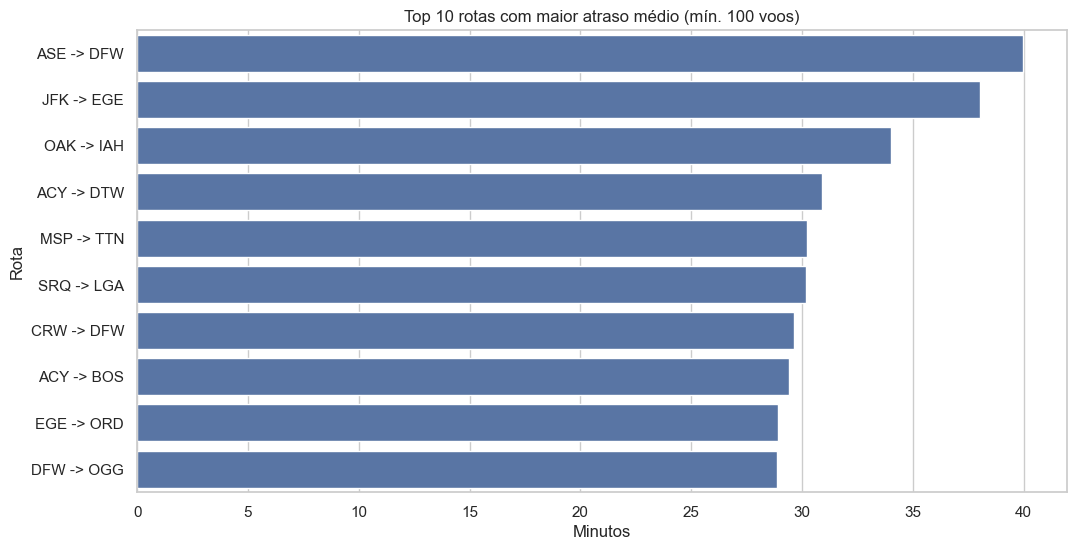

,avg_delay,n_flights
ROUTE,,
ASE -> DFW,39.965649,262
JFK -> EGE,38.009524,105
OAK -> IAH,34.028736,174
ACY -> DTW,30.896552,145
MSP -> TTN,30.225166,151
SRQ -> LGA,30.169048,420
CRW -> DFW,29.615942,138
ACY -> BOS,29.422222,180
EGE -> ORD,28.931373,102


In [73]:
# ============================================================
# 19. Top 10 rotas com maior atraso médio (com filtro de volume)
# ============================================================
route_stats = df_model_base.groupby("ROUTE").agg(
    avg_delay=("ARRIVAL_DELAY", "mean"),
    n_flights=("ROUTE", "size")
)

top_routes = (
    route_stats[route_stats["n_flights"] >= 100]
    .sort_values("avg_delay", ascending=False)
    .head(10)
)

sns.barplot(x=top_routes["avg_delay"].values, y=top_routes.index)
plt.title("Top 10 rotas com maior atraso médio (mín. 100 voos)")
plt.xlabel("Minutos")
plt.ylabel("Rota")
plt.show()

display(top_routes)

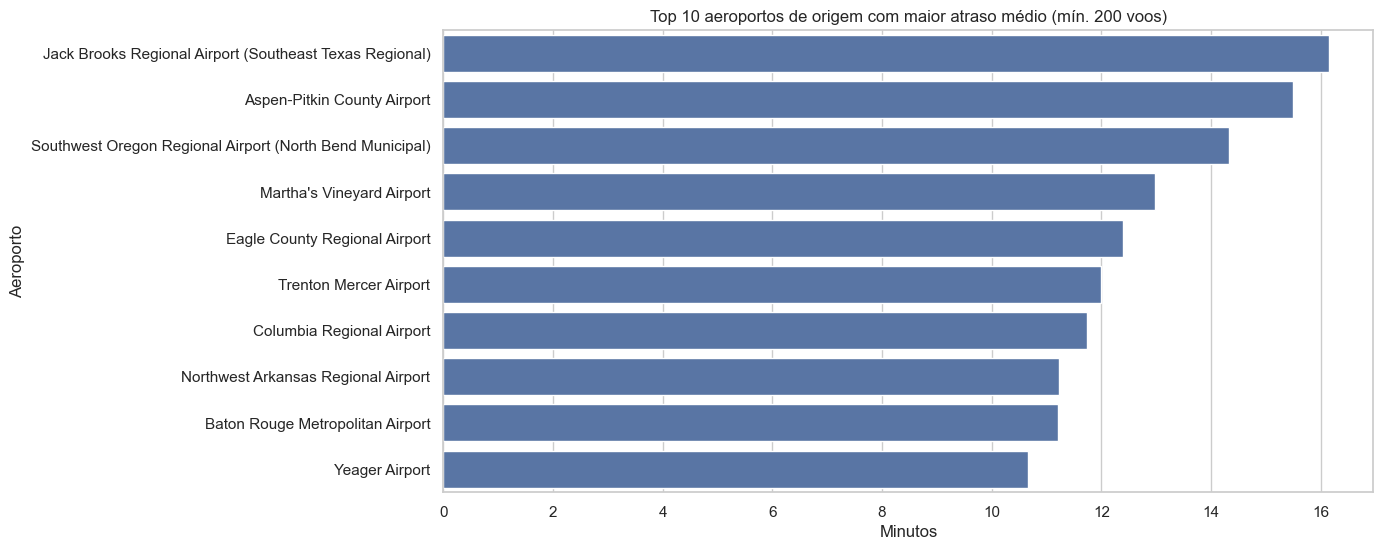

,avg_delay,n_flights
ORIGIN_AIRPORT_NAME,,
Jack Brooks Regional Airport (Southeast Texas Regional),16.154696,905
Aspen-Pitkin County Airport,15.492492,3263
Southwest Oregon Regional Airport (North Bend Municipal),14.333333,264
Martha's Vineyard Airport,12.980488,205
Eagle County Regional Airport,12.401503,1198
Trenton Mercer Airport,11.990256,2771
Columbia Regional Airport,11.746172,1241
Northwest Arkansas Regional Airport,11.233850,8963
Baton Rouge Metropolitan Airport,11.203065,6983


In [74]:
# ============================================================
# 20. Top 10 aeroportos de origem com maior atraso médio (com filtro de volume)
# ============================================================
airport_stats = df_model_base.groupby("ORIGIN_AIRPORT_NAME").agg(
    avg_delay=("ARRIVAL_DELAY", "mean"),
    n_flights=("ORIGIN_AIRPORT_NAME", "size")
)

top_origin_delay = (
    airport_stats[airport_stats["n_flights"] >= 200]
    .sort_values("avg_delay", ascending=False)
    .head(10)
)

sns.barplot(x=top_origin_delay["avg_delay"].values, y=top_origin_delay.index)
plt.title("Top 10 aeroportos de origem com maior atraso médio (mín. 200 voos)")
plt.xlabel("Minutos")
plt.ylabel("Aeroporto")
plt.show()

display(top_origin_delay)

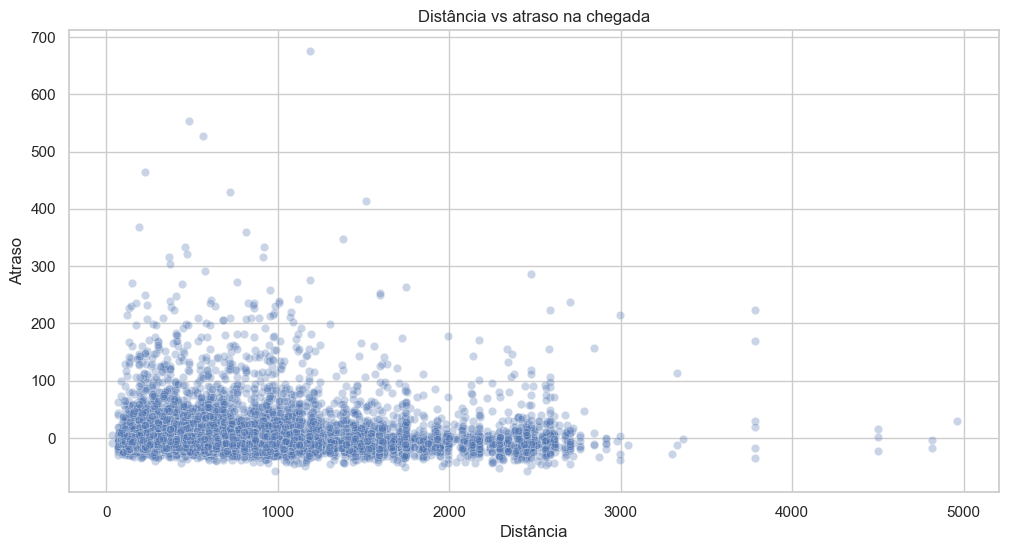

In [ ]:
# ============================================================
# 21. Distância vs atraso
# ============================================================

# amostra opcional para acelerar localmente
sample_df = df_model_base.sample(min(10000, len(df_model_base)), random_state=42)

sns.scatterplot(data=sample_df, x="DISTANCE", y="ARRIVAL_DELAY", alpha=0.3)
plt.title("Distância vs atraso na chegada")
plt.xlabel("Distância")
plt.ylabel("Atraso")
plt.show()

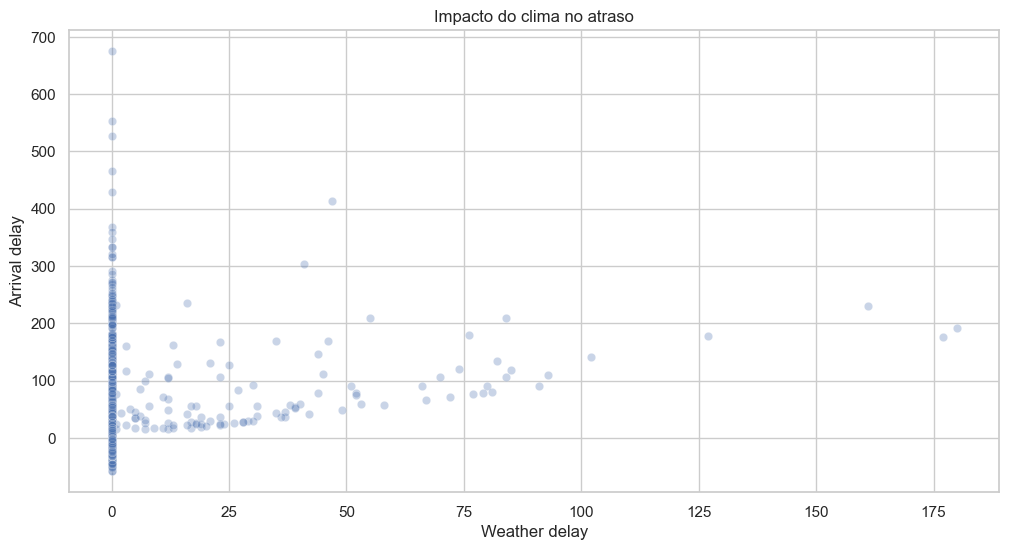

In [76]:
# ============================================================
# 22. Clima vs atraso
# ============================================================
sns.scatterplot(data=sample_df, x="WEATHER_DELAY", y="ARRIVAL_DELAY", alpha=0.3)
plt.title("Impacto do clima no atraso")
plt.xlabel("Weather delay")
plt.ylabel("Arrival delay")
plt.show()

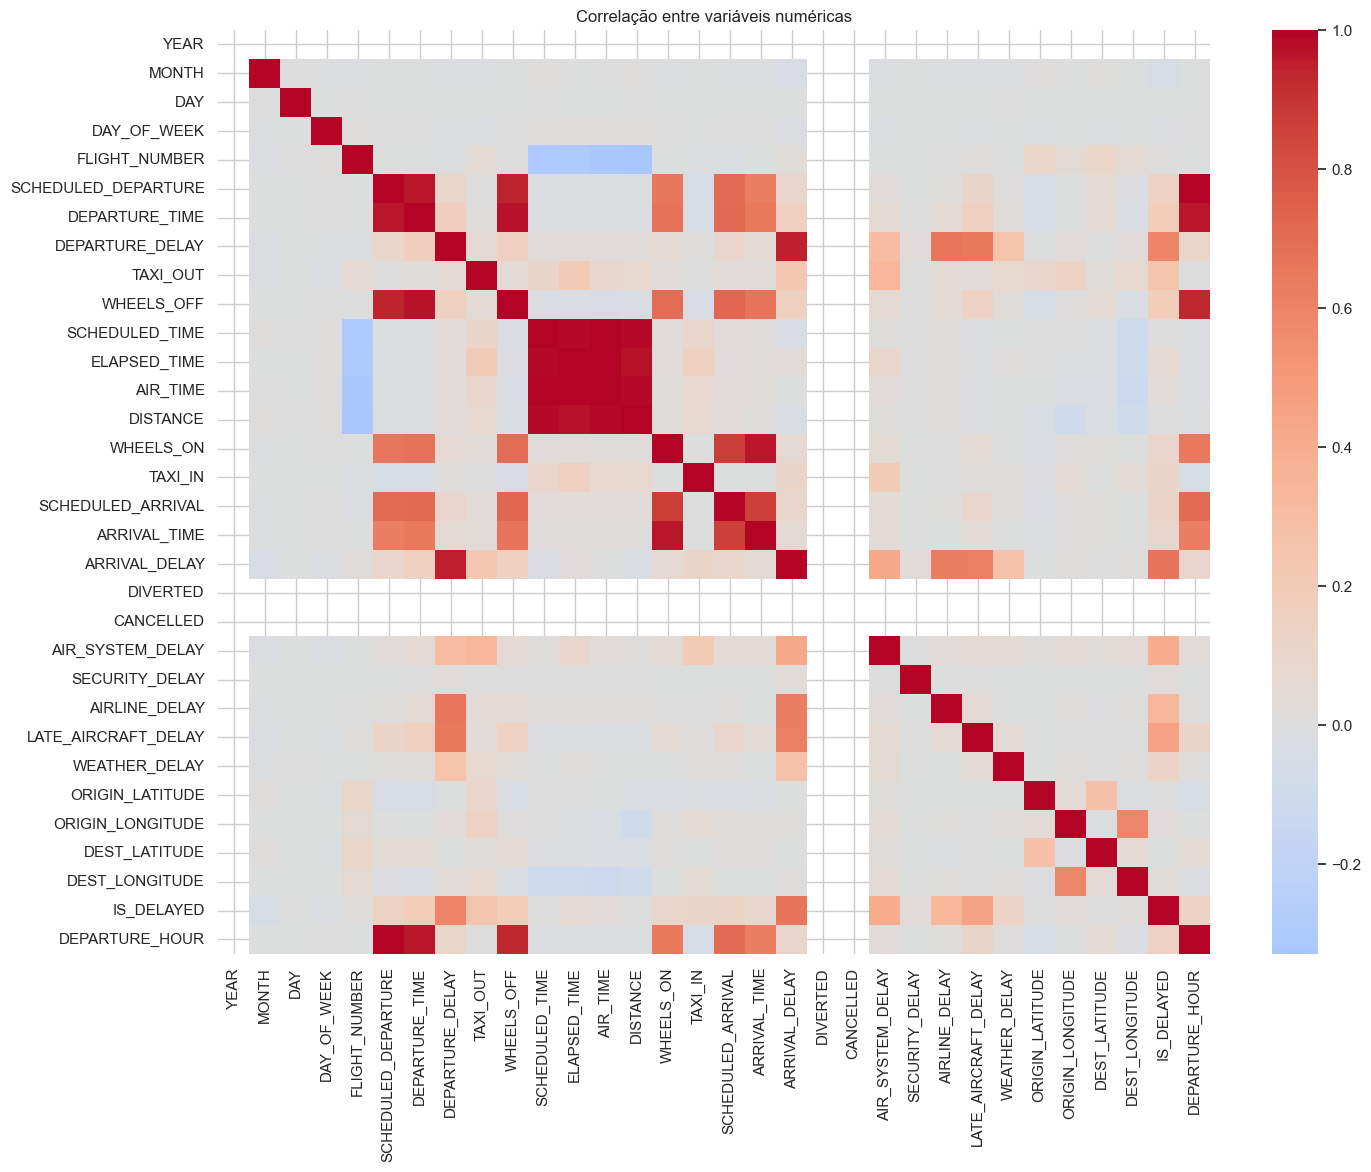

In [77]:
# ============================================================
# 23. Correlação entre variáveis numéricas
# ============================================================
numeric_df = df_model_base.select_dtypes(include=[np.number])
corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis numéricas")
plt.show()

## Conclusões do EDA

In [ ]:
print("Principais insights do EDA:")
print("- A distribuição de atrasos é assimétrica, com muitos voos pontuais e uma cauda longa de atrasos severos.")
print("- Há diferenças relevantes entre companhias aéreas, tanto no atraso médio quanto na taxa de atrasos.")
print("- O atraso tende a aumentar ao longo do dia, sendo mais elevado no período da noite.")
print("- Na madrugada os vôos tendem a se antecipar e no período da manhã mais pontuais.")
print("- O clima impacta atrasos em casos específicos, principalmente em situações extremas, mas não é o principal fator na maioria dos voos.")
print("- Certas rotas e aeroportos concentram atrasos mais elevados, indicando padrões operacionais específicos.")

Principais insights do EDA:
- A distribuição de atrasos é assimétrica, com muitos voos pontuais e uma cauda longa de atrasos severos.
- Algumas companhias aéreas apresentam atrasos médios e taxas de atraso maiores que outras.
- O período do dia influencia o atraso, especialmente em horários mais tardios.
- O clima tem relação visível com o aumento dos atrasos.
- Certas rotas e aeroportos concentram atrasos mais elevados.


# Modelagem supervisionada

## Preparação

Para a classificação, foi adotado um cenário mais conservador, utilizando apenas variáveis que podem ser conhecidas antes do voo, evitando leakage.

Para reduzir a alta cardinalidade das variáveis categóricas, os aeroportos foram substituídos pelas cidades correspondentes na modelagem supervisionada. Essa abordagem reduz a dimensionalidade do one-hot encoding e melhora a eficiência computacional, mantendo capacidade explicativa.

Para a regressão, foram considerados apenas voos com atraso positivo, pois o objetivo é prever quanto tempo o atraso dura.

In [79]:
# ============================================================
# 25. Redução de cardinalidade das cidades para modelagem
# ============================================================
top_origin_cities = df_model_base["ORIGIN_CITY"].value_counts().nlargest(50).index
top_dest_cities = df_model_base["DEST_CITY"].value_counts().nlargest(50).index

df_model_base["ORIGIN_CITY_MODEL"] = df_model_base["ORIGIN_CITY"].apply(
    lambda x: x if x in top_origin_cities else "Other"
)

df_model_base["DEST_CITY_MODEL"] = df_model_base["DEST_CITY"].apply(
    lambda x: x if x in top_dest_cities else "Other"
)

## Classificação

In [ ]:
# ============================================================
# 26. Base e features da classificação
# ============================================================
model_features_class = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE_NAME",
    "ORIGIN_CITY_MODEL",
    "DEST_CITY_MODEL",
    "DISTANCE",
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_HOUR",
    "PERIOD"
]

target_class = "IS_DELAYED"

ml_df_class = df_model_base[model_features_class + [target_class]].copy()
ml_df_class = ml_df_class.dropna()

# amostra opcional para acelerar localmente
ml_df_class = ml_df_class.sample(min(100000, len(ml_df_class)), random_state=42)

X_class = ml_df_class[model_features_class]
y_class = ml_df_class[target_class]

X_train_cls, X_test_cls, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class
)

print("Treino classificação:", X_train_cls.shape)
print("Teste classificação:", X_test_cls.shape)

Treino classificação: (80000, 10)
Teste classificação: (20000, 10)


In [81]:
# ============================================================
# 27. Pré-processamento da classificação
# ============================================================
categorical_features_class = [
    "AIRLINE_NAME",
    "ORIGIN_CITY_MODEL",
    "DEST_CITY_MODEL",
    "PERIOD"
]

numeric_features_class = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DISTANCE",
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_HOUR"
]

numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_no_scale = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_class_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features_class),
        ("cat", categorical_transformer, categorical_features_class)
    ]
)

preprocessor_class_no_scale = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_no_scale, numeric_features_class),
        ("cat", categorical_transformer, categorical_features_class)
    ]
)

In [82]:
# ============================================================
# 28. Modelos de classificação
# ============================================================
clf_logistic = Pipeline(steps=[
    ("preprocessor", preprocessor_class_scaled),
    ("model", LogisticRegression(
        max_iter=500,
        solver="saga",
        n_jobs=-1,
        class_weight="balanced"
    ))
])

clf_rf = Pipeline(steps=[
    ("preprocessor", preprocessor_class_no_scale),
    ("model", RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ))
])

clf_logistic.fit(X_train_cls, y_train_class)
clf_rf.fit(X_train_cls, y_train_class)

pred_log = clf_logistic.predict(X_test_cls)
pred_rf = clf_rf.predict(X_test_cls)

proba_log = clf_logistic.predict_proba(X_test_cls)[:, 1]
proba_rf = clf_rf.predict_proba(X_test_cls)[:, 1]

In [83]:
# ============================================================
# 29. Avaliação da classificação
# ============================================================
results_class = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [
        accuracy_score(y_test_class, pred_log),
        accuracy_score(y_test_class, pred_rf)
    ],
    "Precision": [
        precision_score(y_test_class, pred_log, zero_division=0),
        precision_score(y_test_class, pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_class, pred_log, zero_division=0),
        recall_score(y_test_class, pred_rf, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_class, pred_log, zero_division=0),
        f1_score(y_test_class, pred_rf, zero_division=0)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test_class, proba_log),
        roc_auc_score(y_test_class, proba_rf)
    ]
})

display(results_class.sort_values("F1", ascending=False))

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.58945,0.240953,0.608207,0.345163,0.631489
1,Random Forest Classifier,0.82210,0.000000,0.000000,0.000000,0.639728


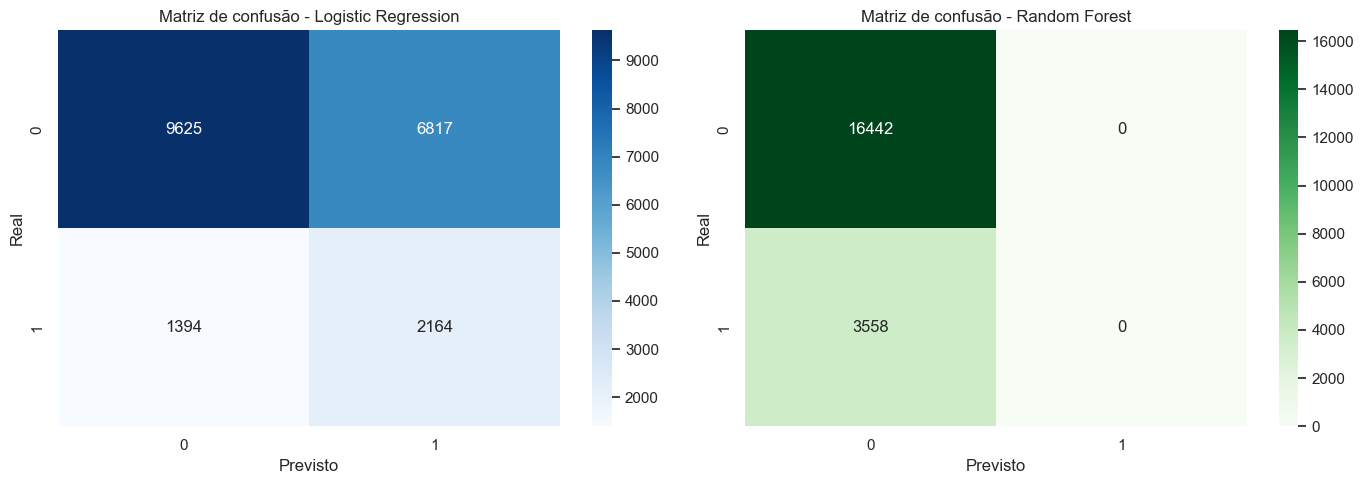

In [84]:
# ============================================================
# 30. Matrizes de confusão
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test_class, pred_log), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de confusão - Logistic Regression")
axes[0].set_xlabel("Previsto")
axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test_class, pred_rf), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Matriz de confusão - Random Forest")
axes[1].set_xlabel("Previsto")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

In [85]:
# ============================================================
# 31. Classification report detalhado
# ============================================================
print("Logistic Regression")
print(classification_report(y_test_class, pred_log, zero_division=0))

print("Random Forest Classifier")
print(classification_report(y_test_class, pred_rf, zero_division=0))

Logistic Regression
              precision    recall  f1-score   support

           0       0.87      0.59      0.70     16442
           1       0.24      0.61      0.35      3558

    accuracy                           0.59     20000
   macro avg       0.56      0.60      0.52     20000
weighted avg       0.76      0.59      0.64     20000

Random Forest Classifier
              precision    recall  f1-score   support

           0       0.82      1.00      0.90     16442
           1       0.00      0.00      0.00      3558

    accuracy                           0.82     20000
   macro avg       0.41      0.50      0.45     20000
weighted avg       0.68      0.82      0.74     20000



,feature,importance
4,num__SCHEDULED_DEPARTURE,0.198755
5,num__DEPARTURE_HOUR,0.114601
0,num__MONTH,0.075299
1,num__DAY,0.069360
124,cat__PERIOD_Noite,0.055991
123,cat__PERIOD_Manhã,0.053413
3,num__DISTANCE,0.052627
2,num__DAY_OF_WEEK,0.042971
10,cat__AIRLINE_NAME_Delta Air Lines Inc.,0.022381
15,cat__AIRLINE_NAME_Southwest Airlines Co.,0.016701


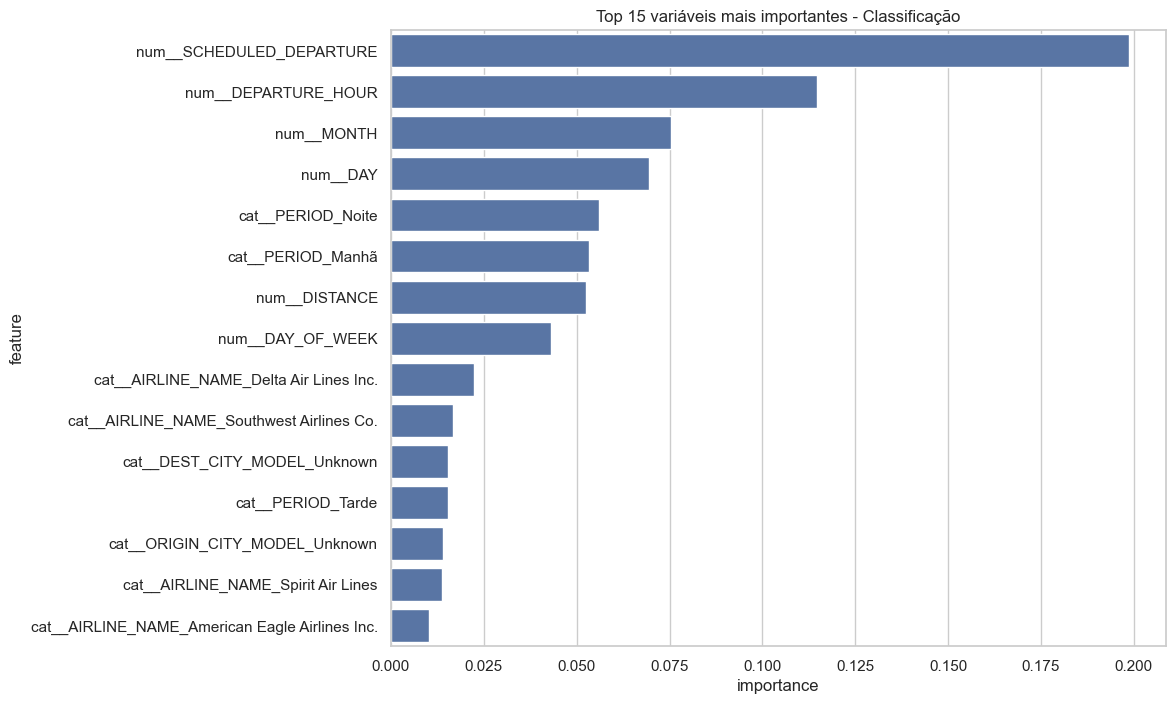

In [86]:
# ============================================================
# 32. Importância das variáveis - classificação Random Forest
# ============================================================
rf_model = clf_rf.named_steps["model"]
rf_preprocessor = clf_rf.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 variáveis mais importantes - Classificação")
plt.show()

## Regressão

In [ ]:
# ============================================================
# 33. Base e features da regressão (voos com atraso positivo)
# ============================================================
df_reg = df_model_base[df_model_base["ARRIVAL_DELAY"] > 0].copy()

model_features_reg = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE_NAME",
    "ORIGIN_CITY_MODEL",
    "DEST_CITY_MODEL",
    "DISTANCE",
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_HOUR",
    "PERIOD",
    "DEPARTURE_DELAY",
    "TAXI_OUT",
    "AIR_TIME"
]

target_reg = "ARRIVAL_DELAY"

ml_df_reg = df_reg[model_features_reg + [target_reg]].copy()
ml_df_reg = ml_df_reg.dropna()

# amostra opcional para acelerar localmente
ml_df_reg = ml_df_reg.sample(min(100000, len(ml_df_reg)), random_state=42)

X_reg = ml_df_reg[model_features_reg]
y_reg = ml_df_reg[target_reg]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Treino regressão:", X_train_reg.shape)
print("Teste regressão:", X_test_reg.shape)

Treino regressão: (80000, 13)
Teste regressão: (20000, 13)


In [88]:
# ============================================================
# 34. Pré-processamento da regressão
# ============================================================
categorical_features_reg = [
    "AIRLINE_NAME",
    "ORIGIN_CITY_MODEL",
    "DEST_CITY_MODEL",
    "PERIOD"
]

numeric_features_reg = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "DISTANCE",
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_HOUR",
    "DEPARTURE_DELAY",
    "TAXI_OUT",
    "AIR_TIME"
]

preprocessor_reg_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features_reg),
        ("cat", categorical_transformer, categorical_features_reg)
    ]
)

preprocessor_reg_no_scale = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_no_scale, numeric_features_reg),
        ("cat", categorical_transformer, categorical_features_reg)
    ]
)

In [89]:
# ============================================================
# 35. Modelos de regressão
# ============================================================
reg_linear = Pipeline(steps=[
    ("preprocessor", preprocessor_reg_scaled),
    ("model", LinearRegression())
])

reg_rf = Pipeline(steps=[
    ("preprocessor", preprocessor_reg_no_scale),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

reg_linear.fit(X_train_reg, y_train_reg)
reg_rf.fit(X_train_reg, y_train_reg)

pred_linear = reg_linear.predict(X_test_reg)
pred_rf_reg = reg_rf.predict(X_test_reg)

In [90]:
# ============================================================
# 36. Avaliação da regressão
# ============================================================
rmse_linear = np.sqrt(mean_squared_error(y_test_reg, pred_linear))
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, pred_rf_reg))

results_reg = pd.DataFrame({
    "Modelo": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [
        mean_absolute_error(y_test_reg, pred_linear),
        mean_absolute_error(y_test_reg, pred_rf_reg)
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf
    ],
    "R2": [
        r2_score(y_test_reg, pred_linear),
        r2_score(y_test_reg, pred_rf_reg)
    ]
})

display(results_reg.sort_values("RMSE"))

,Modelo,MAE,RMSE,R2
0,Linear Regression,6.625976,9.429054,0.967173
1,Random Forest Regressor,6.800984,10.029064,0.962862


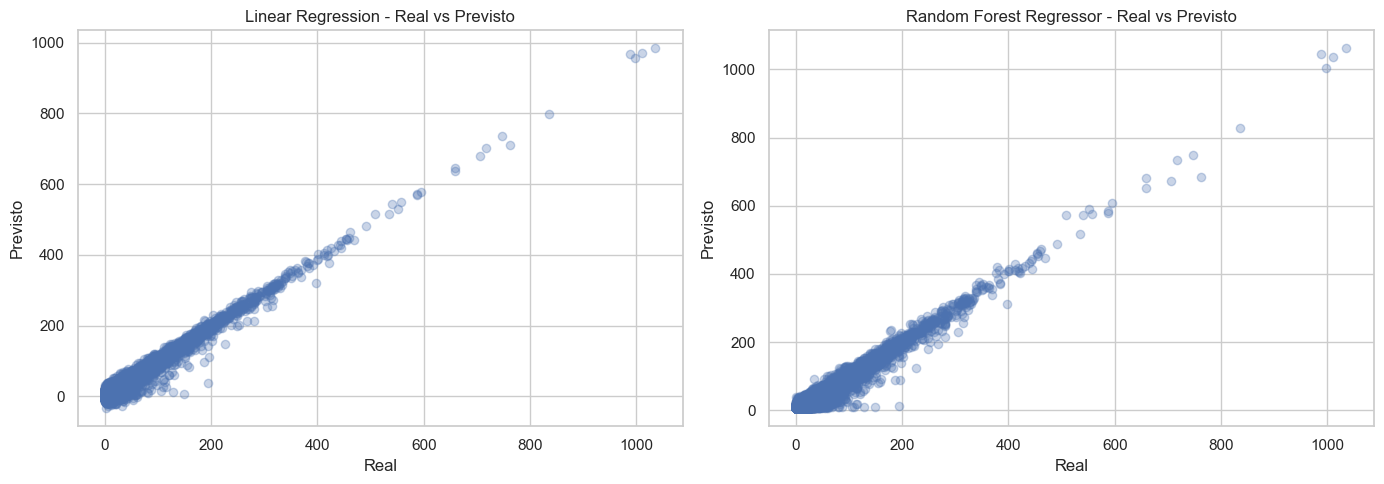

In [91]:
# ============================================================
# 37. Real vs previsto - regressão
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test_reg, pred_linear, alpha=0.3)
axes[0].set_title("Linear Regression - Real vs Previsto")
axes[0].set_xlabel("Real")
axes[0].set_ylabel("Previsto")

axes[1].scatter(y_test_reg, pred_rf_reg, alpha=0.3)
axes[1].set_title("Random Forest Regressor - Real vs Previsto")
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Previsto")

plt.tight_layout()
plt.show()

,feature,importance
6,num__DEPARTURE_DELAY,0.960379
7,num__TAXI_OUT,0.026920
3,num__DISTANCE,0.002610
8,num__AIR_TIME,0.002379
4,num__SCHEDULED_DEPARTURE,0.000710
51,cat__ORIGIN_CITY_MODEL_New York,0.000656
1,num__DAY,0.000625
0,num__MONTH,0.000490
2,num__DAY_OF_WEEK,0.000313
21,cat__AIRLINE_NAME_United Air Lines Inc.,0.000260


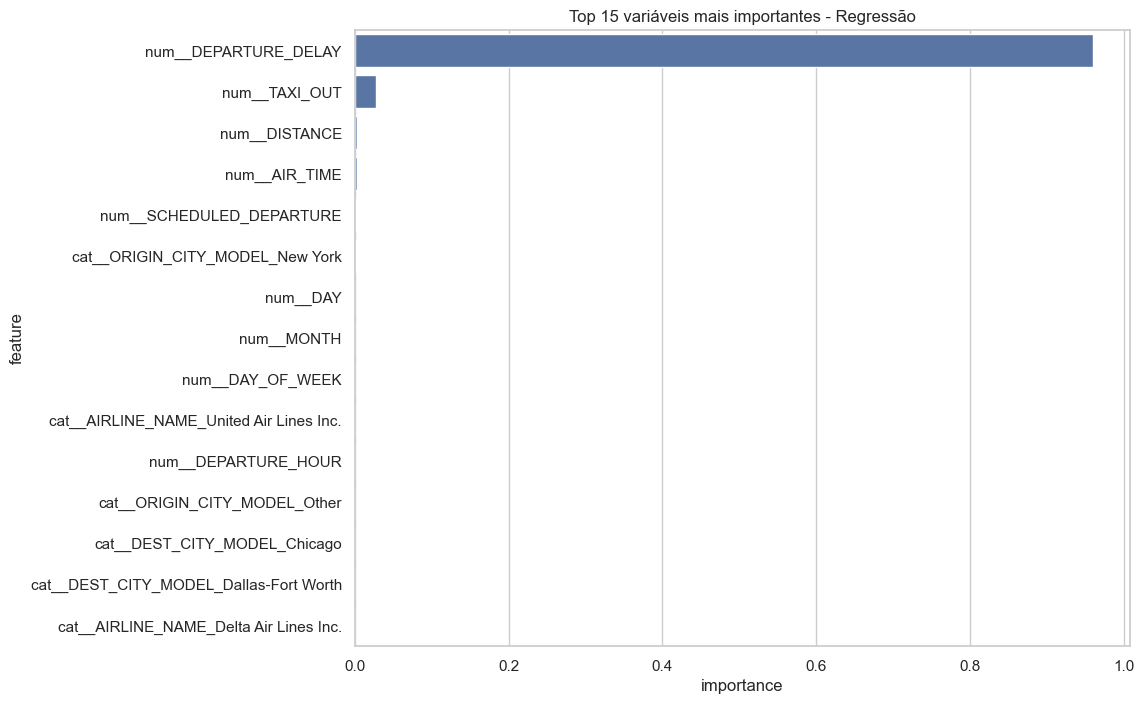

In [92]:
# ============================================================
# 38. Importância das variáveis - regressão Random Forest
# ============================================================
rf_reg_model = reg_rf.named_steps["model"]
rf_reg_preprocessor = reg_rf.named_steps["preprocessor"]

feature_names_reg = rf_reg_preprocessor.get_feature_names_out()
importances_reg = rf_reg_model.feature_importances_

importance_reg_df = pd.DataFrame({
    "feature": feature_names_reg,
    "importance": importances_reg
}).sort_values("importance", ascending=False)

display(importance_reg_df.head(20))

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_reg_df.head(15), x="importance", y="feature")
plt.title("Top 15 variáveis mais importantes - Regressão")
plt.show()

# Modelagem não supervisionada

## Objetivo

Nesta etapa, o objetivo é identificar padrões ocultos nos dados sem utilizar uma variável alvo.

Foi aplicada uma combinação de:
- PCA, para reduzir a dimensionalidade e visualizar os dados
- KMeans, para agrupar aeroportos com comportamentos semelhantes

O PCA foi utilizado para projeção bidimensional e visualização dos clusters; a clusterização foi realizada sobre os dados padronizados.

In [93]:
# ============================================================
# 39. Preparação dos dados para clusterização
# ============================================================
cluster_df = df_model_base.groupby("ORIGIN_AIRPORT").agg(
    ARRIVAL_DELAY=("ARRIVAL_DELAY", "mean"),
    DEPARTURE_DELAY=("DEPARTURE_DELAY", "mean"),
    DISTANCE=("DISTANCE", "mean"),
    AIR_TIME=("AIR_TIME", "mean"),
    WEATHER_DELAY=("WEATHER_DELAY", "mean"),
    DELAY_RATE=("IS_DELAYED", "mean"),
    N_FLIGHTS=("ORIGIN_AIRPORT", "size")
).reset_index()

cluster_df = cluster_df[cluster_df["N_FLIGHTS"] >= 200].copy()

display(cluster_df.head())
print("Quantidade de aeroportos usados na clusterização:", cluster_df.shape[0])

,ORIGIN_AIRPORT,ARRIVAL_DELAY,DEPARTURE_DELAY,DISTANCE,AIR_TIME,WEATHER_DELAY,DELAY_RATE,N_FLIGHTS
0,10135,6.564854,9.372385,596.447699,97.979079,0.000000,0.163180,239
2,10140,0.704709,5.886427,730.336288,98.250970,0.310803,0.124654,1805
8,10158,-4.755102,-0.044898,836.048980,115.836735,0.000000,0.065306,245
11,10185,0.543165,3.510791,342.140288,56.643885,0.169065,0.143885,278
12,10208,2.959641,0.542601,143.000000,33.721973,0.112108,0.125561,223


Quantidade de aeroportos usados na clusterização: 487


In [94]:
# ============================================================
# 40. Padronização dos dados
# ============================================================
features_cluster = [
    "ARRIVAL_DELAY",
    "DEPARTURE_DELAY",
    "DISTANCE",
    "AIR_TIME",
    "WEATHER_DELAY",
    "DELAY_RATE"
]

X_cluster = cluster_df[features_cluster]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

,k,silhouette_score
0,2,0.293964
1,3,0.287372
2,4,0.292787
3,5,0.271565
4,6,0.243363


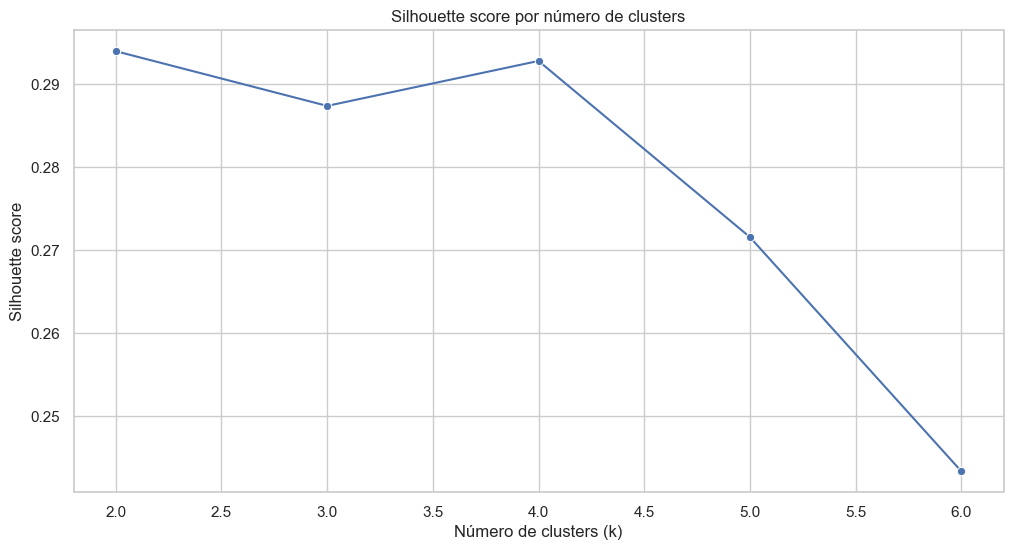

Melhor k escolhido: 2


In [95]:
# ============================================================
# 41. Escolha de k com silhouette score
# ============================================================
silhouette_scores = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouette_scores[k] = silhouette_score(X_scaled, labels)

silhouette_df = pd.DataFrame({
    "k": list(silhouette_scores.keys()),
    "silhouette_score": list(silhouette_scores.values())
})

display(silhouette_df)

sns.lineplot(data=silhouette_df, x="k", y="silhouette_score", marker="o")
plt.title("Silhouette score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.show()

best_k = silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)

print("Melhor k escolhido:", best_k)

In [96]:
# ============================================================
# 42. PCA
# ============================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variância explicada pelos componentes:", pca.explained_variance_ratio_)
print("Variância explicada total:", pca.explained_variance_ratio_.sum())

Variância explicada pelos componentes: [0.46868655 0.34791672]
Variância explicada total: 0.8166032651123092


In [97]:
# ============================================================
# 43. KMeans
# ============================================================
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

cluster_df["CLUSTER"] = clusters

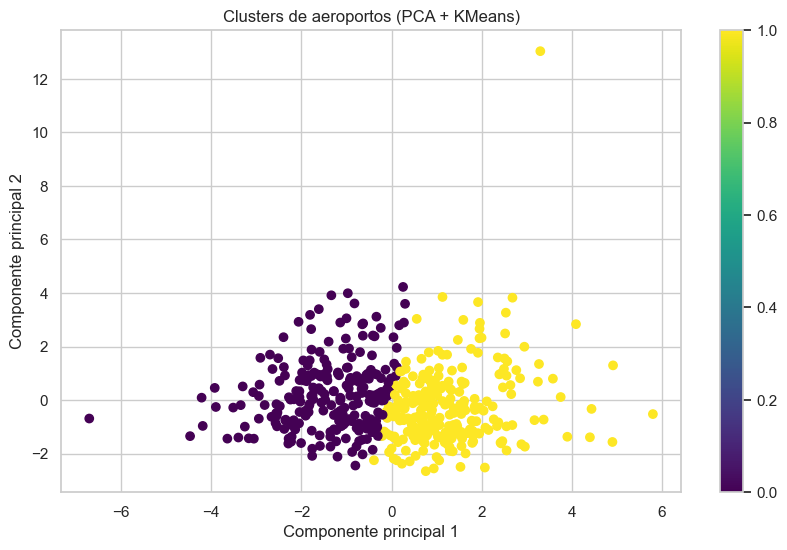

In [98]:
# ============================================================
# 44. Visualização dos clusters com PCA
# ============================================================
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=cluster_df["CLUSTER"],
    cmap="viridis"
)

plt.title("Clusters de aeroportos (PCA + KMeans)")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.colorbar(scatter)
plt.show()

In [99]:
# ============================================================
# 45. Características médias por cluster
# ============================================================
cluster_summary = cluster_df.groupby("CLUSTER").agg({
    "ARRIVAL_DELAY": "mean",
    "DEPARTURE_DELAY": "mean",
    "DISTANCE": "mean",
    "AIR_TIME": "mean",
    "WEATHER_DELAY": "mean",
    "DELAY_RATE": "mean",
    "N_FLIGHTS": "mean"
}).round(3)

display(cluster_summary)

,ARRIVAL_DELAY,DEPARTURE_DELAY,DISTANCE,AIR_TIME,WEATHER_DELAY,DELAY_RATE,N_FLIGHTS
CLUSTER,,,,,,,
0,-0.844,3.071,575.714,84.313,0.236,0.111,3788.026
1,5.796,8.569,531.505,80.533,0.581,0.179,19092.603


In [100]:
# ============================================================
# 46. Interpretação automática dos clusters
# ============================================================
print("Interpretação dos clusters:")
for cluster_id in cluster_summary.index:
    row = cluster_summary.loc[cluster_id]
    print(f"Cluster {cluster_id}:")
    print(f"- ARRIVAL_DELAY médio: {row['ARRIVAL_DELAY']}")
    print(f"- DEPARTURE_DELAY médio: {row['DEPARTURE_DELAY']}")
    print(f"- DELAY_RATE médio: {row['DELAY_RATE']}")
    print(f"- WEATHER_DELAY médio: {row['WEATHER_DELAY']}")
    print(f"- DISTANCE média: {row['DISTANCE']}")
    print(f"- N_FLIGHTS médio: {row['N_FLIGHTS']}")

Interpretação dos clusters:
Cluster 0:
- ARRIVAL_DELAY médio: -0.844
- DEPARTURE_DELAY médio: 3.071
- DELAY_RATE médio: 0.111
- WEATHER_DELAY médio: 0.236
- DISTANCE média: 575.714
- N_FLIGHTS médio: 3788.026
Cluster 1:
- ARRIVAL_DELAY médio: 5.796
- DEPARTURE_DELAY médio: 8.569
- DELAY_RATE médio: 0.179
- WEATHER_DELAY médio: 0.581
- DISTANCE média: 531.505
- N_FLIGHTS médio: 19092.603


## Interpretação dos clusters

A clusterização permitiu identificar perfis distintos de aeroportos.

A interpretação deve ser feita com base na tabela de médias por cluster:
- clusters com maior `ARRIVAL_DELAY` e maior `DELAY_RATE` representam aeroportos com operação mais crítica
- clusters com menores médias de atraso representam aeroportos mais eficientes
- O cluster 1 apresenta maior ARRIVAL_DELAY e DELAY_RATE, indicando aeroportos com operação mais crítica e maior incidência de atrasos.
- O cluster 0 apresenta atrasos médios próximos ou negativos e menor taxa de atraso, representando aeroportos mais eficientes.
- diferenças em `DISTANCE` e `AIR_TIME` podem indicar perfis de rotas mais longas ou hubs operacionais
- `N_FLIGHTS` ajuda a contextualizar o porte médio dos aeroportos em cada grupo

# Comparação final dos modelos

In [101]:
# ============================================================
# 47. Comparação final dos modelos
# ============================================================
print("Resultados finais - Classificação")
display(results_class.sort_values("F1", ascending=False))

print("Resultados finais - Regressão")
display(results_reg.sort_values("RMSE", ascending=True))

Resultados finais - Classificação


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.58945,0.240953,0.608207,0.345163,0.631489
1,Random Forest Classifier,0.82210,0.000000,0.000000,0.000000,0.639728


Resultados finais - Regressão


,Modelo,MAE,RMSE,R2
0,Linear Regression,6.625976,9.429054,0.967173
1,Random Forest Regressor,6.800984,10.029064,0.962862


In [ ]:
# ============================================================
# 48. Conclusões finais automáticas
# ============================================================
best_class_model = results_class.sort_values("F1", ascending=False).iloc[0]
best_reg_model = results_reg.sort_values("RMSE", ascending=True).iloc[0]

print("Conclusões finais:")
print(f"- No problema de classificação, o modelo Logistic Regression apresentou melhor desempenho, pois conseguiu identificar voos atrasados, enquanto o Random Forest apresentou colapso na classe minoritária, prevendo apenas a classe majoritária.")
print(f"- No problema de regressão, o modelo Linear Regression apresentou melhor desempenho, com menores valores de MAE e RMSE, além de alto R², indicando boa capacidade de explicação da variabilidade dos dados.")
print("- O EDA foi fundamental para selecionar variáveis relevantes e orientar a modelagem.")
print("- A modelagem supervisionada permitiu prever atraso e duração do atraso.")
print("- A modelagem não supervisionada permitiu segmentar aeroportos com padrões operacionais semelhantes.")

Conclusões finais:
- No problema de classificação, o melhor modelo foi Logistic Regression, considerando principalmente F1 e ROC_AUC.
- No problema de regressão, o melhor modelo foi Linear Regression, considerando principalmente RMSE e MAE.
- O EDA foi fundamental para selecionar variáveis relevantes e orientar a modelagem.
- A modelagem supervisionada permitiu prever atraso e duração do atraso.
- A modelagem não supervisionada permitiu segmentar aeroportos com padrões operacionais semelhantes.


# Conclusão

Este projeto explorou a base de dados de voos em três níveis:

1. EDA: compreensão dos dados, tratamento de valores ausentes e geração de insights relevantes  
2. Modelagem supervisionada:
   - classificação para prever a ocorrência de atrasos  
   - regressão para prever a duração do atraso  
3. Modelagem não supervisionada:
   - clusterização de aeroportos utilizando PCA e KMeans  

Os resultados mostraram que:
- o atraso de voos depende de múltiplos fatores, como companhia aérea, horário do voo, distância e características operacionais
- na classificação, o modelo Logistic Regression apresentou melhor desempenho, enquanto o Random Forest teve dificuldade em identificar a classe minoritária (voos atrasados)
- na regressão, o modelo Linear Regression apresentou melhor desempenho, com bons resultados de MAE, RMSE e R²
- a análise exploratória foi essencial para orientar a seleção de variáveis e entender o comportamento dos dados
- a clusterização permitiu identificar grupos distintos de aeroportos, com diferentes níveis de atraso e padrões operacionais

Dessa forma, o projeto demonstra uma pipeline completa de análise de dados e machine learning, desde a exploração inicial até a modelagem supervisionada e não supervisionada, gerando insights interpretáveis e aplicáveis ao problema de atrasos em voos.